Used car dataset shape (426880, 18)
Used car dataset shape (426880, 18)
Original unique models: 5284
Cleaned unique models: 2381
 Before Score clean up: (2187, 15)
Checking for outliers in columns: ['price', 'odometer']
 After Score clean up: (2144, 15)
fuel: 4 unique values
title_status: 5 unique values
transmission: 3 unique values
model_cleaned: 121 unique values
condition: 3 unique values
type: 7 unique values
size: 2 unique values
drive: 3 unique values
paint_color: 10 unique values
mean squared error 50864341.49
Best parameters found: {'impute__n_neighbors': 1, 'model__n_neighbors': 2}
Best cross-validation score (Accuracy): 0.6912
Train MSE: 14354319.24
Test MSE: 50864341.49
R2_score train: 0.92
R2_score test: 0.70
Actual price 46000.0. Predicted price for a car : 46000.00
Actual price 48000.0. Predicted price for a car : 45450.00


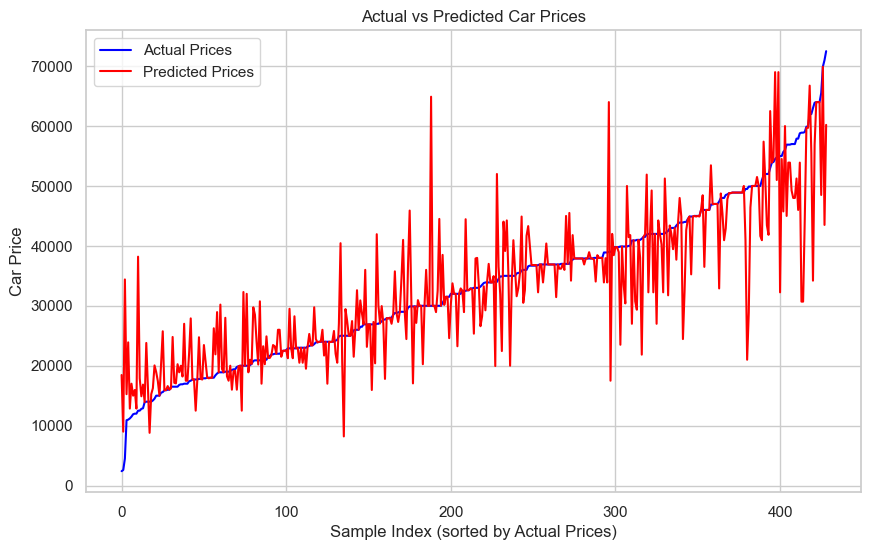

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'impute__n_neighbors': [1], 'model__n_neighbors': [2]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [3]:
#### Changing the direction of data selection to use all features like condition, type, size, drive, paint_color, state
import re
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, OrdinalEncoder

from helpers.data_cleaners import summary_stats
from helpers.data_eda import remove_outliers_by_zscore, visualize_missing_values, draw_distribution_chart
from helpers.unsupervised import pca_recommendation_visualization
from sklearn.preprocessing import FunctionTransformer

# Set basic configuration to display the plots in the same notebook
sns.set_theme(style="whitegrid")
# Setting the plots to display in same notebook
%matplotlib inline

warnings.filterwarnings('ignore')

from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsRegressor

# Load the used car dataset
data_more_columns = pd.read_csv('data/vehicles.csv')
print(f"Used car dataset shape {data_more_columns.shape}")

#Data understanding and cleaning

# 1. viualize_missing_values(data_more_columns)
#data_more_columns.dropna(inplace=True)

print(f"Used car dataset shape {data_more_columns.shape}")
#viualize_missing_values(data_more_columns)

# 2. Clean the 'price' and 'odometer' column by removing '$' and ',' and converting to float
data_more_columns['price'] = data_more_columns['price'].astype(str).str.replace('[$,]', '', regex=True).astype(float)
data_more_columns['odometer'] = data_more_columns['odometer'].astype(str).str.replace('[,]', '', regex=True).astype(float)
data_more_columns['price'] = pd.to_numeric(data_more_columns['price'], errors='coerce')
data_more_columns['odometer'] = pd.to_numeric(data_more_columns['odometer'], errors='coerce')

# 3. Calculate age of the car from 'year' column
data_more_columns['age'] = data_more_columns['year'].apply(lambda x: datetime.now().year - x if pd.notnull(x) else x)

# 4. scope the data range in age, odometer and price
data_more_columns= data_more_columns[data_more_columns['price']>1500]
data_more_columns= data_more_columns[data_more_columns['odometer']<100000]
data_more_columns= data_more_columns[data_more_columns['age']<8]

data_more_columns['odometer'] = data_more_columns['odometer'].round(-3)
data_more_columns['price'] = data_more_columns['price'].round(-2)

# 5. Drop irrelevant columns and remove rarely used 'size' column
data_more_columns.drop(columns=['id','region','VIN', 'year','state'],inplace=True)

# 1. Convert everything to lowercase
data_more_columns['model_cleaned'] = data_more_columns['model'].str.lower()
data_more_columns['manufacturer'] = data_more_columns['manufacturer'].str.lower()

# 2. Remove leading/trailing whitespaces
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.strip()
data_more_columns['manufacturer'] = data_more_columns['manufacturer'].str.strip()

# 3. Remove common punctuation and symbols (optional, but helpful)
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace(r'[^\w\s]', '', regex=True) # Keeps letters, numbers, spaces
data_more_columns['manufacturer'] = data_more_columns['manufacturer'].str.replace(r'[^\w\s]', '', regex=True) # Keeps letters, numbers, spaces

# 4. Remove common redundant words or phrases
# E.g., remove "sedan", "suv", "4x4", "trim", "edition" if they aren't necessary
redundant_terms = ['sedan', 'suv', 'truck', '4x4', 'awd', 'fwd', 'rwd', 'ltd',
                   'xlt', 'sxt', 'lx', 'ex', 'edition', 'trim', 'sport', 'utility',
                   'mechanical', 'model', 'series', 'package', 'pkg', 'type', 'version', 'style', 'count']

for term in redundant_terms:
    # Use word boundaries (\b) to avoid removing parts of other words (e.g., 'port' from 'sportage')
    data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace(rf'\b{term}\b', '', regex=True)

# 5. Collapse multiple spaces into a single space
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace(r'\s+', ' ', regex=True)
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.strip()
data_more_columns['manufacturer'] = data_more_columns['manufacturer'].str.replace(r'\s+', ' ', regex=True)

# 6. Handle specific inconsistencies/typos (Manual Correction)
# Example: If people type 'f150' and 'f-150', standardize it
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('f150', 'f-150')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('silverado1500', 'silverado 1500')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('accordlx', 'accord lx')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('camryse', 'camry se')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('civicex', 'civic ex')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('grandcherokee', 'grand cherokee')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('mustanggt', 'mustang gt')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('explorerxlt', 'explorer xlt')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('crv', 'cr-v')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('wranglerunlimited', 'wrangler unlimited')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('foresterxt', 'forester xt')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('focustitanium', 'focus titanium')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('imprezawsport', 'impreza wsport')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('rav4xle', 'rav4 xle')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('tacoma4x4', 'tacoma 4x4')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('altima25s', 'altima 2.5s')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('malibults', 'malibu lts')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('silverado2500hd', 'silverado 2500hd')
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].str.replace('f-150xlt', 'f-150 xlt')
# continue to improve the list ...

# 7. shorten long model names
def shorten_string_trunc(text, max_len=20):
    if len(text) > max_len:
        return text[:max_len]
    return text.strip()

data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].astype(str)
data_more_columns['model_cleaned'] = data_more_columns['model_cleaned'].apply(lambda x: shorten_string_trunc(x, max_len=10))

# 8. Combine manufacturer and cleaned model for better uniqueness
data_more_columns['model_cleaned'] = data_more_columns['manufacturer'] + ' ' + data_more_columns['model_cleaned']

# Check the unique counts after cleaning
print(f"Original unique models: {data_more_columns['model'].nunique()}")
print(f"Cleaned unique models: {data_more_columns['model_cleaned'].nunique()}")


# 9. Filter out models with less than 100 samples and age with less than 1000 samples
data_more_columns = data_more_columns.groupby('model_cleaned').filter(lambda x :len(x)>100)
data_more_columns = data_more_columns.groupby('age').filter(lambda x :len(x)>500)
data_more_columns = data_more_columns.groupby('transmission').filter(lambda x :len(x)>200)
data_more_columns = data_more_columns.groupby('paint_color').filter(lambda x :len(x)>100)
data_more_columns = data_more_columns.groupby('condition').filter(lambda x :len(x)>500)
data_more_columns = data_more_columns.groupby('type').filter(lambda x :len(x)>500)
data_more_columns = data_more_columns.groupby('drive').filter(lambda x :len(x)>500)
data_more_columns = data_more_columns.groupby('size').filter(lambda x :len(x)>500)


# 6. remove outliers
print (f" Before Score clean up: {data_more_columns.shape}")
data_more_columns = remove_outliers_by_zscore(data_more_columns, threshold=3, columns=['price', 'odometer'])  
print (f" After Score clean up: {data_more_columns.shape}")

#data_more_columns = data_more_columns.sample(frac=0.3, random_state=42)

categorical_cols = [ 'fuel', 'title_status', 'transmission', 'model_cleaned','condition','type','size','drive','paint_color']
numeric_features = ['age','odometer']

for col in categorical_cols:
    print(f"{col}: {data_more_columns[col].nunique()} unique values")

X = data_more_columns[['age', 'odometer', 'fuel', 'title_status', 'transmission', 'model_cleaned','condition','type','size','drive','paint_color']]
y = data_more_columns['price']


# 7. Split data into training and testing sets
X_train_more_columns, X_test_more_columns, y_train_more_columns, y_test_more_columns = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Building
train_mses = []
test_mses = []

preprocessor = ColumnTransformer(
    transformers=[
       
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols) # Changed back to OneHotEncoder
    ],
    remainder='drop', # Drops any columns not specified above
    sparse_threshold=0 
)

#  Using GridSearchCV tune hyperparameter tuning

#1. create GridSearchCV with poly feature degree and ridge_alpha

def to_dense_ft(X):
    # Converts input to float32 immediately upon conversion
    if hasattr(X, 'toarray'):
        return X.toarray().astype(np.float32) # Downcast to float32
    return X.astype(np.float32) # Downcast to float3
dense_transformer = FunctionTransformer(to_dense_ft, accept_sparse=True)

imputer_pipe = Pipeline([('transform', preprocessor),  
            ('to_dense', dense_transformer),
            ('impute', KNNImputer()),  
            ('model', KNeighborsRegressor())])

params = {'model__n_neighbors': [2],
         'impute__n_neighbors': [1]}
model_finder = GridSearchCV(imputer_pipe, param_grid=params, error_score='raise')

#2. Train the model
model_finder.fit(X_train_more_columns, y_train_more_columns)

preds = model_finder.predict(X_test_more_columns)
imputer_mse = mean_squared_error(y_test_more_columns, preds)
print(f'mean squared error {imputer_mse:.2f}')

print(f"Best parameters found: {model_finder.best_params_}")
print(f"Best cross-validation score (Accuracy): {model_finder.best_score_:.4f}" )
#print(model_finder.cv_results_)

# 3. predict using train and test data
best_model_with_more_columns = model_finder.best_estimator_
best_train_pred=best_model_with_more_columns.predict(X_train_more_columns)
best_test_pred=best_model_with_more_columns.predict(X_test_more_columns)

best_train_mse = mean_squared_error(y_train_more_columns, best_train_pred)
best_test_mse = mean_squared_error(y_test_more_columns, best_test_pred)
print(f"Train MSE: {best_train_mse:.2f}")
print(f"Test MSE: {best_test_mse:.2f}")

print(f"R2_score train: {r2_score(y_train_more_columns, best_train_pred):.2f}")
print(f"R2_score test: {r2_score(y_test_more_columns, best_test_pred):.2f}")
#sanity  data check with known values

##sanity  data check with known values
print(f"Actual price {y_train_more_columns.iloc[5]}. Predicted price for a car : {best_train_pred[5]:.2f}")
print(f"Actual price {y_test_more_columns.iloc[6]}. Predicted price for a car : {best_test_pred[6]:.2f}")

#visualize actual and predictions in sorted order using line plot
sorted_indices = np.argsort(y_test_more_columns)
y_test_sorted = y_test_more_columns.iloc[sorted_indices]
yhat_sorted = best_test_pred[sorted_indices]
plt.figure(figsize=(10,6))
plt.plot(y_test_sorted.values, label='Actual Prices', color='blue')
plt.plot(yhat_sorted, label='Predicted Prices', color='red')
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Sample Index (sorted by Actual Prices)')
plt.ylabel('Car Price')
plt.legend()
plt.show()

model_finder

In [2]:
visualize the residuals
# 1. Residual Analysis
# Calculate residuals
residuals = y_test_more_columns - best_test_pred

plt.figure(figsize=(14, 6))

# Residuals vs Predicted Plot
plt.subplot(1, 2, 1)
plt.scatter(best_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Prices')

# Histogram of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (319551997.py, line 1)